# Consensus Score Active Experiment

이 노트북은 컨센서스 기반 스코어 하나를 어떻게 비중에 반영할지 실험합니다.

처음에는 아래 세 변수만 쓴 스코어에서 출발했습니다.

$$
ConsensusScore_{i,t}
= 0.50 z(EPSRevision1M_{i,t})
+ 0.30 z(TargetUpside_{i,t})
+ 0.20 z(RatingPoint_{i,t})
$$

### 왜 50 / 30 / 20인가

이 가중치는 성과가 가장 좋은 조합을 사후적으로 찾아낸 최적화 값이 아니라, 컨센서스 신호의 성격을 반영한 **사전적인 신호 우선순위**입니다.

| 신호 | 가중치 | 이유 |
|---|---:|---|
| EPS revision 1M | 50% | 가장 최근의 이익 추정치 상향/하향입니다. 전력설비 기업의 수주, 마진, 실적 기대 변화가 EPS 추정치에 가장 직접적으로 반영된다고 봤기 때문에 가장 크게 둡니다. |
| Target upside | 30% | 목표주가는 애널리스트의 장기 실적/밸류에이션 판단이 섞인 신호입니다. 다만 목표주가는 늦게 바뀌고 낙관적으로 유지되는 경향이 있어 EPS revision보다 낮게 둡니다. |
| Rating point | 20% | 투자의견은 buy/hold/sell처럼 단계가 거칠고 천천히 움직입니다. 방향 확인용 보조 신호로 쓰되, 단독으로 포트폴리오를 지배하지 않게 가장 낮게 둡니다. |

즉 구조는 “가장 빠른 이익 전망 변화 50%, 애널리스트의 가격 판단 30%, 느리지만 안정적인 의견 신호 20%”입니다. 세 가중치의 합은 1이 되도록 두어 점수 해석이 투명하게 유지되도록 했습니다.

성과가 안 나왔던 핵심 원인은 스코어 자체만이 아니라, 처음 세팅이 너무 보수적이었다는 점입니다. 월말 리밸런싱과 작은 active budget에서는 ETF PDF와 거의 같은 포트폴리오가 되므로 성과 차이가 거의 나지 않습니다.

그래서 실험에서는 ETF PDF 비중에 스코어 multiplier를 곱하는 방식과, 같은 스코어를 공분산 기반 MVO 최적화로 비중화하는 방식을 비교했습니다.

$$
TargetWeight_{i,t}
\propto PDFWeight_{i,t}
\times \exp(\gamma \times ConsensusScore_{i,t})
$$

즉 PDF 비중을 버리는 것이 아니라, 기존 ETF 비중을 출발점으로 두고 점수가 높은 종목의 비중을 더 강하게 키웁니다. 최종 후보는 이 score 방향을 MVO 최적화 목적식에 넣어 PDF 대비 active weight를 결정합니다.

추가로 한국시장 팩터 연구에서 자주 나오는 사이즈, 밸류, 수익성, 저위험, earnings revision momentum 아이디어도 현재 데이터로 가능한 proxy로 비교했습니다.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

OUTPUT = Path('output')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

def pct(x):
    return '' if pd.isna(x) else f'{x:.2%}'

def num(x):
    return '' if pd.isna(x) else f'{x:.3f}'

def fmt_table(df, pct_cols=None, num_cols=None):
    out = df.copy()
    for col in pct_cols or []:
        if col in out.columns:
            out[col] = out[col].map(pct)
    for col in num_cols or []:
        if col in out.columns:
            out[col] = out[col].map(num)
    return out

## 0. 재실행 옵션

아래 값을 `True`로 바꾸면 실험을 다시 실행합니다.

In [2]:
RUN_EXPERIMENTS = False

if RUN_EXPERIMENTS:
    import active_experiment_runner
    import active_te_overlay_experiment
    active_experiment_runner.run_all_active_experiments()
    active_te_overlay_experiment.run_active_te_overlay_experiments()

## 1. 신호 자체의 검증

먼저 세 개 신호와 합성 스코어가 다음 리밸런싱 구간의 종목 수익률 순위와 어떤 관계가 있는지 봅니다.

`IC(Information Coefficient)`는 팩터가 이후 수익률을 설명하는 정보력을 얼마나 가지고 있는지 보는 지표입니다. 이 프로젝트에서는 “점수가 높은 종목이 다음 리밸런싱 구간에도 실제로 더 좋은 수익률을 냈는가?”를 확인하기 위해 IC를 사용합니다.

계산 순서는 다음입니다.

```text
1. 리밸런싱일에 종목별 factor score를 계산
2. 같은 날짜 안에서 factor score 순위를 매김
3. 다음 리밸런싱 구간의 종목별 실제 수익률을 계산
4. 실제 수익률 순위를 매김
5. 두 순위의 Spearman rank correlation을 계산
```

`Spearman rank correlation`은 원래 값의 크기 자체를 비교하는 상관계수가 아니라, **순위가 얼마나 같이 움직였는지**를 보는 상관계수입니다. 예를 들어 어떤 날짜에 EPS revision 점수가 1등, 2등, 3등인 종목들이 다음 달 수익률에서도 대체로 상위권이면 Spearman 값은 양수가 됩니다. 반대로 점수가 높았던 종목들이 다음 달 수익률 하위권으로 밀리면 음수가 됩니다.

이 프로젝트에서 `Spearman IC`는 다음 두 순위의 상관입니다.

```text
리밸런싱일의 factor score 순위
vs
다음 리밸런싱 구간의 종목 수익률 순위
```

즉 IC가 양수라는 것은 “점수가 높았던 종목이 이후 수익률도 상대적으로 좋았다”는 뜻입니다. ETF 구성종목 수가 10여 개로 적고, factor 값에 이상치가 있을 수 있기 때문에 원값의 선형관계를 보는 Pearson correlation보다 순위 기반 Spearman correlation이 더 안정적입니다.

In [3]:
ic = pd.read_csv(OUTPUT / 'consensus_score_signal_ic_summary.csv')
display(fmt_table(
    ic,
    pct_cols=['hit_ratio_ic_positive', 'mean_top_minus_bottom_return', 'hit_ratio_top_minus_bottom_positive'],
    num_cols=['mean_ic', 'median_ic'],
))

,factor,observations,mean_ic,median_ic,hit_ratio_ic_positive,mean_top_minus_bottom_return,hit_ratio_top_minus_bottom_positive
0,eps_growth_fy2_vs_fy0,20,0.175,0.183,65.00%,1.47%,60.00%
1,analyst_coverage,22,0.166,0.119,68.18%,2.09%,54.55%
2,ni_growth_fy2_vs_fy0,20,0.162,0.179,65.00%,2.79%,55.00%
3,sales_current_year_e,22,0.158,0.233,68.18%,3.24%,72.73%
4,sales_next_year_e,22,0.157,0.233,72.73%,3.10%,72.73%
5,log_market_cap,22,0.151,0.245,72.73%,2.12%,72.73%
6,rating_total_count,22,0.147,0.131,59.09%,0.92%,59.09%
7,sales_spread_fy1_minus_fy0,22,0.146,0.150,68.18%,1.90%,59.09%
8,target_total_count,22,0.145,0.118,59.09%,0.92%,59.09%
9,target_confidence,22,0.135,0.081,59.09%,0.66%,59.09%


## 1-1. Score가 만들어지는 공통 절차

모든 score는 같은 방식으로 만듭니다. 중요한 점은 **절대값 비교가 아니라 같은 날짜의 ETF 구성종목 내부 상대 비교**라는 것입니다.

### Step 1. 리밸런싱일의 ETF 구성종목만 사용

각 리밸런싱일마다 KRX PDF에 있는 ETF 구성종목을 기준 universe로 둡니다. 즉 한국시장 전체에서 종목을 새로 고르는 것이 아니라, ETF가 이미 담고 있는 종목 안에서 비중만 조정합니다.

### Step 2. 원자료 factor를 만든다

예를 들어 EPS revision 1M은 다음처럼 계산합니다.

$$
EPSRevision1M_{i,t}
=
\frac{
EPSNextYearE_{i,t} - EPSNextYearE_{i,t-21}
}{
|EPSNextYearE_{i,t-21}|
}
$$

여기서 21거래일은 대략 1개월입니다. 즉 “다음 연도 EPS 컨센서스가 최근 한 달 동안 얼마나 상향/하향됐는가”를 봅니다.

목표주가 괴리율은 FnGuide의 목표주가괴리율을 사용합니다.

$$
TargetUpside_{i,t}
=
\frac{TargetPrice_{i,t} - Price_{i,t}}{Price_{i,t}}
$$

투자의견 점수는 FnGuide의 `투자의견(포인트)`를 사용합니다. 일반적으로 값이 높을수록 애널리스트 의견이 우호적이라고 해석합니다.

### Step 3. 같은 날짜의 종목들끼리 z-score로 표준화

각 factor는 단위가 다릅니다. EPS revision은 %, 목표주가 괴리율도 %, 투자의견은 점수입니다. 그래서 바로 더하지 않고 cross-sectional z-score로 바꿉니다.

$$
z(x_{i,t})
=
\frac{x_{i,t} - \bar{x}_t}{\sigma_t}
$$

여기서 평균과 표준편차는 같은 날짜의 ETF 구성종목들로만 계산합니다. 결측값은 먼저 그 날짜의 중앙값으로 채운 뒤 z-score를 계산합니다. 정보가 없는 종목을 극단적으로 좋거나 나쁘게 처리하지 않기 위해서입니다.

### Step 4. 방향을 맞춘다

값이 클수록 좋은 factor는 그대로 씁니다. 변동성처럼 값이 낮을수록 좋은 factor는 부호를 반대로 둡니다.

예:

$$
z^{good}(Volatility) = -z(Volatility)
$$

### Step 5. 가중합으로 score를 만든다

각 표준화 factor에 가중치를 곱해서 더합니다.

$$
Score_{i,t}
=
\sum_f \alpha_f \cdot z(f_{i,t})
$$

가중치 합은 1이 되도록 정규화합니다.

$$
\sum_f \alpha_f = 1
$$

이렇게 하면 score가 “몇 개 factor 중 무엇을 얼마나 반영했는지” 해석 가능합니다.

## 1-2. 실험한 Score Profile 정의

### A. `consensus_core`

최종 전략의 핵심 score입니다.

$$
ConsensusCore_{i,t}
=
0.50z(EPSRevision1M_{i,t})
+0.30z(TargetUpside_{i,t})
+0.20z(RatingPoint_{i,t})
$$

| 구성 factor | 가중치 | 계산/의미 |
|---|---:|---|
| `eps_revision_1m` | 50% | 다음 연도 EPS 컨센서스의 21거래일 변화율. 이익 전망이 최근 상향되는 종목을 선호 |
| `target_upside` | 30% | 목표주가괴리율. 현재가 대비 목표주가 여력이 큰 종목을 선호 |
| `rating_point` | 20% | 투자의견 포인트. 애널리스트 의견이 더 우호적인 종목을 선호 |

이 score를 쓰는 실험은 다음입니다.

| 실험 | 설명 |
|---|---|
| `consensus_multiplier_defensive` | 같은 score를 약하게 반영 |
| `consensus_multiplier_balanced` | 같은 score를 중간 강도로 반영 |
| `consensus_multiplier_return_focus` | 같은 score를 강하게 반영 |
| `consensus_return_focus_te_budget` | 같은 score를 강하게 반영하되 규칙형 active TE budget으로 위험 관리 |
| `consensus_active_mvo_te20_ra1` | 같은 score를 benchmark-relative MVO 최적화로 비중화한 최종 후보 |

즉 위 네 전략은 **팩터가 다른 것이 아니라 score를 비중에 반영하는 강도가 다른 것**입니다.

### B. `earnings_revision_momentum_proxy`

이익 전망 상향 모멘텀을 더 넓게 잡은 score입니다.

$$
RevisionMomentumProxy_{i,t}
=
0.40z(EPSRevision1M)
+0.20z(EPSRevision3M)
+0.15z(OPRevision3M)
+0.10z(TargetPriceRevision21D)
+0.10z(TargetUpside)
+0.05z(RatingRevisionBalance)
$$

| 구성 factor | 가중치 | 계산/의미 |
|---|---:|---|
| `eps_revision_1m` | 40% | 다음 연도 EPS 컨센서스의 1개월 변화 |
| `eps_revision_3m` | 20% | 현재 연도 EPS 컨센서스의 63거래일 변화 |
| `op_revision_3m` | 15% | 현재 연도 영업이익 컨센서스의 63거래일 변화 |
| `target_price_revision_21d` | 10% | 목표주가의 21거래일 변화율 |
| `target_upside` | 10% | 현재가 대비 목표주가 여력 |
| `rating_revision_balance` | 5% | 투자의견 상향수와 하향수의 균형 |

이 score는 EPS 한 달 변화만 보기에는 정보가 부족할 수 있어서, 영업이익과 목표주가 revision까지 확장한 후보입니다. 다만 최종 발표의 중심은 더 단순하고 설명 가능한 `consensus_core`입니다.

### C. Risk-adjusted score 후보

추가로 변동성/낙폭을 score 자체에 벌점으로 넣은 후보도 테스트했습니다.

예:

$$
ConsensusRiskAdjusted
=
0.40z(EPSRevision1M)
+0.25z(TargetUpside)
+0.15z(RatingPoint)
+0.10z(Drawdown60D)
-0.10z(Volatility20D)
$$

하지만 이 방식은 Sharpe를 유의미하게 개선하지 못했습니다. 그래서 최종 전략에서는 score 자체에 리스크 벌점을 강하게 넣기보다, **score는 수익률 신호로 유지하고 공분산 기반 active risk 최적화를 별도 비중화 레이어로 붙이는 방식**을 선택했습니다.

## 2. 비중 반영 방식과 성과

아래 표는 성과가 안 좋았던 월말/약한 active 후보와 현재 ETF 유니버스에서 성과가 약했던 연구 proxy 후보를 제거하고, 발표에서 볼 만한 multiplier 후보와 MVO 최적화 후보만 남긴 결과입니다.

여기서는 초과성과를 두 가지로 나눠 봅니다.

- `excess_cumulative_return_pct_point`: 전략 누적수익률 - PDF 누적수익률입니다. 예를 들어 전략 632.53%, PDF 495.88%이면 +136.66%p입니다.
- `relative_active_cumulative_return`: 최종 wealth ratio 기준 초과성과입니다. 같은 예에서 `(1+6.1605)/(1+4.9588)-1 = +20.17%`입니다.

발표에서 “PDF보다 몇 %p 더 벌었나”를 말할 때는 `excess_cumulative_return_pct_point`를 쓰는 것이 직관적입니다.

해석상 가장 중요한 비교는 다음입니다.

- `consensus_multiplier_defensive`: TE와 상관계수를 비교적 안정적으로 유지하는 방어형 후보입니다.
- `consensus_multiplier_balanced`: 누적수익률과 IR의 균형이 좋은 비교 후보입니다.
- `revision_momentum_proxy_balanced`: EPS/OP revision과 target revision을 이용한 revision momentum proxy입니다.
- `consensus_multiplier_return_focus`: 성과를 더 키운 공격형 후보입니다.
- `consensus_return_focus_te_budget`: 공격형 후보에 규칙형 active TE 예산 관리를 붙인 비교 후보입니다.
- `consensus_active_mvo_te20_ra1`: 같은 consensus score를 공분산과 TE 제약 안에서 최적화한 최종 후보입니다.

In [4]:
summary = pd.read_csv(OUTPUT / 'advanced_experiment_presentation_summary.csv')
summary = summary.sort_values('cumulative_return', ascending=False).copy()
cols = [
    'experiment_name',
    'score_profile',
    'cumulative_return',
    'benchmark_cumulative_return',
    'excess_cumulative_return_pct_point',
    'relative_active_cumulative_return',
    'tracking_error',
    'information_ratio',
    'correlation',
    'average_turnover',
    'average_active_te_scale',
    'min_active_te_scale',
    'optimizer_success_rate',
    'average_optimizer_predicted_te',
    'max_drawdown',
    'average_abs_active_weight',
    'max_abs_active_weight',
    'rebalance_frequency',
    'target_method',
    'score_gamma',
    'individual_max_weight',
    'one_way_turnover_limit',
]
display(fmt_table(
    summary[cols],
    pct_cols=[
        'cumulative_return',
        'benchmark_cumulative_return',
        'excess_cumulative_return_pct_point',
        'relative_active_cumulative_return',
        'tracking_error',
        'average_turnover',
        'average_active_te_scale',
        'min_active_te_scale',
        'max_drawdown',
        'average_abs_active_weight',
        'max_abs_active_weight',
        'individual_max_weight',
        'one_way_turnover_limit',
    ],
    num_cols=['information_ratio', 'correlation', 'score_gamma'],
))

,experiment_name,score_profile,cumulative_return,benchmark_cumulative_return,excess_cumulative_return_pct_point,relative_active_cumulative_return,tracking_error,information_ratio,correlation,average_turnover,average_active_te_scale,min_active_te_scale,optimizer_success_rate,average_optimizer_predicted_te,max_drawdown,average_abs_active_weight,max_abs_active_weight,rebalance_frequency,target_method,score_gamma,individual_max_weight,one_way_turnover_limit
3,consensus_active_mvo_te20_ra1,consensus_core,632.53%,495.88%,136.66%,22.93%,17.01%,0.734,0.952,5.01%,100.00%,100.00%,1.0,0.199882,-33.88%,8.18%,48.78%,weekly,active_mvo_te,0.800,70.00%,30.00%
6,consensus_active_mvo_te16_ra1,consensus_core,595.30%,495.88%,99.42%,16.69%,13.91%,0.663,0.968,4.46%,100.00%,100.00%,1.0,0.160000,-34.05%,6.85%,38.05%,weekly,active_mvo_te,0.800,70.00%,30.00%
4,consensus_active_mvo_te14,consensus_core,586.71%,495.88%,90.84%,15.24%,12.13%,0.700,0.975,4.11%,100.00%,100.00%,1.0,0.138296,-34.69%,6.08%,33.12%,weekly,active_mvo_te,0.800,70.00%,30.00%
5,consensus_return_focus_te_budget,consensus_core,578.29%,495.88%,82.42%,13.83%,12.03%,0.683,0.976,3.83%,98.36%,50.81%,NaN,NaN,-32.23%,4.83%,59.01%,weekly,multiplicative,1.500,70.00%,30.00%
7,consensus_multiplier_return_focus,consensus_core,574.78%,495.88%,78.90%,13.24%,12.82%,0.619,0.973,4.05%,100.00%,100.00%,NaN,NaN,-31.67%,5.21%,59.01%,weekly,multiplicative,1.500,70.00%,30.00%
8,revision_momentum_proxy_return_focus,earnings_revision_momentum_proxy,573.10%,495.88%,77.22%,12.96%,13.86%,0.595,0.970,3.36%,100.00%,100.00%,NaN,NaN,-34.79%,5.53%,46.12%,weekly,multiplicative,1.500,70.00%,30.00%
2,revision_momentum_proxy_balanced,earnings_revision_momentum_proxy,564.92%,495.88%,69.04%,11.59%,9.22%,0.758,0.986,2.26%,100.00%,100.00%,NaN,NaN,-34.54%,3.67%,30.70%,weekly,multiplicative,1.000,50.00%,20.00%
1,consensus_multiplier_balanced,consensus_core,562.51%,495.88%,66.63%,11.18%,8.44%,0.766,0.988,2.69%,100.00%,100.00%,NaN,NaN,-33.52%,3.36%,31.01%,weekly,multiplicative,1.000,50.00%,20.00%
0,consensus_multiplier_defensive,consensus_core,551.51%,495.88%,55.63%,9.34%,6.79%,0.797,0.992,2.16%,100.00%,100.00%,NaN,NaN,-34.24%,2.70%,26.29%,weekly,multiplicative,0.800,50.00%,15.00%


## 2-0. 최종 후보: Consensus active MVO optimization

최종적으로 집중해서 볼 전략은 **`consensus_active_mvo_te20_ra1`**입니다. 아이디어는 단순합니다.

1. ETF PDF 비중을 기준 비중으로 둡니다.
2. 컨센서스 스코어가 높은 종목은 PDF보다 더 담고, 낮은 종목은 덜 담습니다.
3. 다만 공분산 행렬로 계산한 PDF 대비 active risk가 정해진 TE 예산을 넘지 않도록 최적화합니다.

즉 수익률 신호만 쓰는 것이 아니라, **수익률 신호 + 공분산 기반 active risk 최적화**로 갑니다.

### 1. 왜 return_focus인가

`balanced`는 안정적이지만 PDF와 너무 비슷합니다. 이 ETF는 구성종목 수가 많지 않고 같은 테마 종목들이 함께 움직이기 때문에, active weight가 너무 작으면 그래프가 거의 겹치고 초과성과도 작아집니다.

그래서 `return_focus`에서는 같은 consensus score를 더 적극적으로 반영합니다.

| 항목 | balanced | return_focus | 의미 |
|---|---:|---:|---|
| score gamma | 1.0 | 1.5 | 점수를 비중 multiplier로 바꾸는 강도 |
| 개별 최대비중 | 50% | 70% | 강한 신호가 있는 대형 구성종목을 더 담을 수 있게 함 |
| one-way turnover limit | 20% | 30% | 주간 리밸런싱에서 비중 이동 여지를 조금 더 줌 |

여기서 `return_focus`는 새로운 팩터가 아닙니다. **같은 스코어를 더 강하게 비중에 반영한 구현 버전**입니다.

### 2. 왜 MVO 최적화인가

공격형으로 가면 누적수익률은 커지지만 tracking error도 같이 커집니다. active 전략에서 TE는 단순히 나쁜 값이 아니라, 벤치마크와 다르게 움직이는 정도입니다. 그래서 TE 자체보다 “그 TE를 써서 초과수익을 얼마나 얻었는가”, 즉 IR을 같이 봐야 합니다.

그래서 최종 후보에서는 규칙형 scale이 아니라, 공분산 행렬을 이용한 benchmark-relative MVO를 붙였습니다. 이 방식은 score exposure를 키우되, PDF 대비 예상 TE를 제약조건으로 직접 넣습니다.

최적화 목적식은 다음입니다.

$$
\max_{{w_t}}
\quad
s_t^\top (w_t - w^{{PDF}}_t)
- \lambda (w_t - w^{{PDF}}_t)^\top \Sigma_t (w_t - w^{{PDF}}_t)
- \eta \|w_t - w_{{t-1}}\|_2^2
$$

첫 번째 항은 점수가 높은 종목을 더 담을수록 커지는 score exposure입니다. 두 번째 항은 PDF 대비 active variance를 줄이는 위험 벌점입니다. 세 번째 항은 이전 비중에서 너무 크게 움직이지 않게 하는 turnover 벌점입니다.

제약조건은 다음입니다.

$$
\sum_i w_{i,t}=1,
\quad
0 \le w_{i,t} \le 70\%,
\quad
\sqrt{(w_t-w^{PDF}_t)^\top(252\Sigma_t)(w_t-w^{PDF}_t)}
\le 18\%
$$

여기서 20%는 운용사 공식 tracking error 목표가 아닙니다. 이 프로젝트의 active overlay가 PDF 벤치마크에서 얼마나 벗어날 수 있는지 정한 **active risk budget**입니다.

### 3. 최종 target weight 구조

먼저 consensus score를 만듭니다.

$$
ConsensusScore_{i,t}
= 0.50z(EPSRevision1M_{i,t})
+ 0.30z(TargetUpside_{i,t})
+ 0.20z(RatingPoint_{i,t})
$$

각 변수는 같은 날짜의 ETF 구성종목 안에서 cross-sectional z-score로 표준화합니다. 결측값은 그 날짜의 중앙값으로 채워서, 정보가 없는 종목이 극단적으로 좋거나 나쁘게 평가되지 않게 했습니다.

그 다음 MVO 최적화가 최종 비중을 직접 풉니다. 점수가 높은 종목은 PDF 대비 overweight 방향으로, 점수가 낮은 종목은 underweight 방향으로 움직이지만, 움직인 결과의 active risk가 TE budget을 넘지 않도록 제한합니다.

이 방식은 종목을 새로 고르는 모델이 아닙니다. ETF가 이미 고른 구성종목 안에서, 컨센서스 신호가 좋은 종목으로 비중을 더 이동시키되, 그 이동이 포트폴리오 전체 위험을 과도하게 키우지 않도록 최적화하는 구조입니다.

In [5]:
overlay = pd.read_csv(OUTPUT / 'active_te_overlay_selected_summary.csv')
overlay_grid = pd.read_csv(OUTPUT / 'active_te_overlay_experiment_summary.csv')
te_budget = summary[summary['experiment_name'].eq('consensus_return_focus_te_budget')].copy()
base_return_focus = summary[summary['experiment_name'].eq('consensus_multiplier_return_focus')].copy()
balanced = summary[summary['experiment_name'].eq('consensus_multiplier_balanced')].copy()
mvo14 = summary[summary['experiment_name'].eq('consensus_active_mvo_te14')].copy()
mvo20 = summary[summary['experiment_name'].eq('consensus_active_mvo_te20_ra1')].copy()

compare = pd.concat([
    balanced.assign(strategy_type='balanced base'),
    base_return_focus.assign(strategy_type='return_focus base'),
    te_budget.assign(strategy_type='target-weight TE budget'),
    mvo14.assign(strategy_type='active MVO TE 14%'),
    mvo20.assign(strategy_type='final active MVO TE 20%'),
], ignore_index=True)

display(fmt_table(
    compare[[
        'strategy_type',
        'experiment_name',
        'cumulative_return',
        'benchmark_cumulative_return',
        'excess_cumulative_return_pct_point',
        'tracking_error',
        'information_ratio',
        'correlation',
        'sharpe_ratio',
        'average_active_te_scale',
        'min_active_te_scale',
        'optimizer_success_rate',
        'average_optimizer_predicted_te',
        'average_turnover',
        'max_drawdown',
    ]],
    pct_cols=[
        'cumulative_return',
        'benchmark_cumulative_return',
        'excess_cumulative_return_pct_point',
        'tracking_error',
        'average_active_te_scale',
        'min_active_te_scale',
        'optimizer_success_rate',
        'average_optimizer_predicted_te',
        'average_turnover',
        'max_drawdown',
    ],
    num_cols=['information_ratio', 'correlation', 'sharpe_ratio'],
))

print('Return-level overlay selected result: risk budget idea applied directly to the active return sleeve')
display(fmt_table(
    overlay[[
        'experiment_name',
        'base_experiment',
        'cumulative_return',
        'benchmark_cumulative_return',
        'excess_cumulative_return_pct_point',
        'tracking_error',
        'information_ratio',
        'correlation',
        'sharpe_ratio',
        'average_active_scale',
        'te_target',
        'lookback_days',
    ]],
    pct_cols=[
        'cumulative_return',
        'benchmark_cumulative_return',
        'excess_cumulative_return_pct_point',
        'tracking_error',
        'average_active_scale',
        'te_target',
    ],
    num_cols=['information_ratio', 'correlation', 'sharpe_ratio'],
))
print('Top overlay grid candidates')
display(fmt_table(
    overlay_grid.head(10)[[
        'experiment_name',
        'base_experiment',
        'cumulative_return',
        'excess_cumulative_return_pct_point',
        'tracking_error',
        'information_ratio',
        'sharpe_ratio',
        'average_active_scale',
        'te_target',
        'lookback_days',
    ]],
    pct_cols=[
        'cumulative_return',
        'excess_cumulative_return_pct_point',
        'tracking_error',
        'average_active_scale',
        'te_target',
    ],
    num_cols=['information_ratio', 'sharpe_ratio'],
))

,strategy_type,experiment_name,cumulative_return,benchmark_cumulative_return,excess_cumulative_return_pct_point,tracking_error,information_ratio,correlation,sharpe_ratio,average_active_te_scale,min_active_te_scale,optimizer_success_rate,average_optimizer_predicted_te,average_turnover,max_drawdown
0,balanced base,consensus_multiplier_balanced,562.51%,495.88%,66.63%,8.44%,0.766,0.988,3.546,100.00%,100.00%,,,2.69%,-33.52%
1,return_focus base,consensus_multiplier_return_focus,574.78%,495.88%,78.90%,12.82%,0.619,0.973,3.550,100.00%,100.00%,,,4.05%,-31.67%
2,target-weight TE budget,consensus_return_focus_te_budget,578.29%,495.88%,82.42%,12.03%,0.683,0.976,3.569,98.36%,50.81%,,,3.83%,-32.23%
3,active MVO TE 14%,consensus_active_mvo_te14,586.71%,495.88%,90.84%,12.13%,0.700,0.975,3.659,100.00%,100.00%,100.00%,13.83%,4.11%,-34.69%
4,final active MVO TE 20%,consensus_active_mvo_te20_ra1,632.53%,495.88%,136.66%,17.01%,0.734,0.952,3.822,100.00%,100.00%,100.00%,19.99%,5.01%,-33.88%


Return-level overlay selected result: risk budget idea applied directly to the active return sleeve


,experiment_name,base_experiment,cumulative_return,benchmark_cumulative_return,excess_cumulative_return_pct_point,tracking_error,information_ratio,correlation,sharpe_ratio,average_active_scale,te_target,lookback_days
0,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,588.96%,495.88%,93.08%,11.34%,0.791,0.979,3.635,91.05%,12.00%,20


Top overlay grid candidates


,experiment_name,base_experiment,cumulative_return,excess_cumulative_return_pct_point,tracking_error,information_ratio,sharpe_ratio,average_active_scale,te_target,lookback_days
0,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,588.45%,92.57%,11.08%,0.790,3.653,90.87%,12.00%,10
1,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,586.61%,90.73%,11.11%,0.774,3.645,91.28%,12.00%,10
2,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,588.96%,93.08%,11.34%,0.791,3.635,91.05%,12.00%,20
3,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,588.96%,93.08%,11.34%,0.791,3.635,91.05%,12.00%,20
4,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,580.99%,85.12%,10.14%,0.789,3.635,85.54%,10.00%,10
5,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,577.80%,81.92%,10.22%,0.757,3.620,86.41%,10.00%,10
6,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,580.49%,84.62%,10.24%,0.792,3.616,84.91%,10.00%,20
7,consensus_multiplier_return_focus_te_overlay_0...,consensus_multiplier_return_focus,575.76%,79.88%,8.94%,0.845,3.613,75.97%,8.00%,20
8,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,577.71%,81.84%,10.28%,0.766,3.603,85.38%,10.00%,20
9,consensus_multiplier_return_focus_te_overlay_1...,consensus_multiplier_return_focus,579.52%,83.64%,11.51%,0.702,3.603,93.71%,12.00%,10


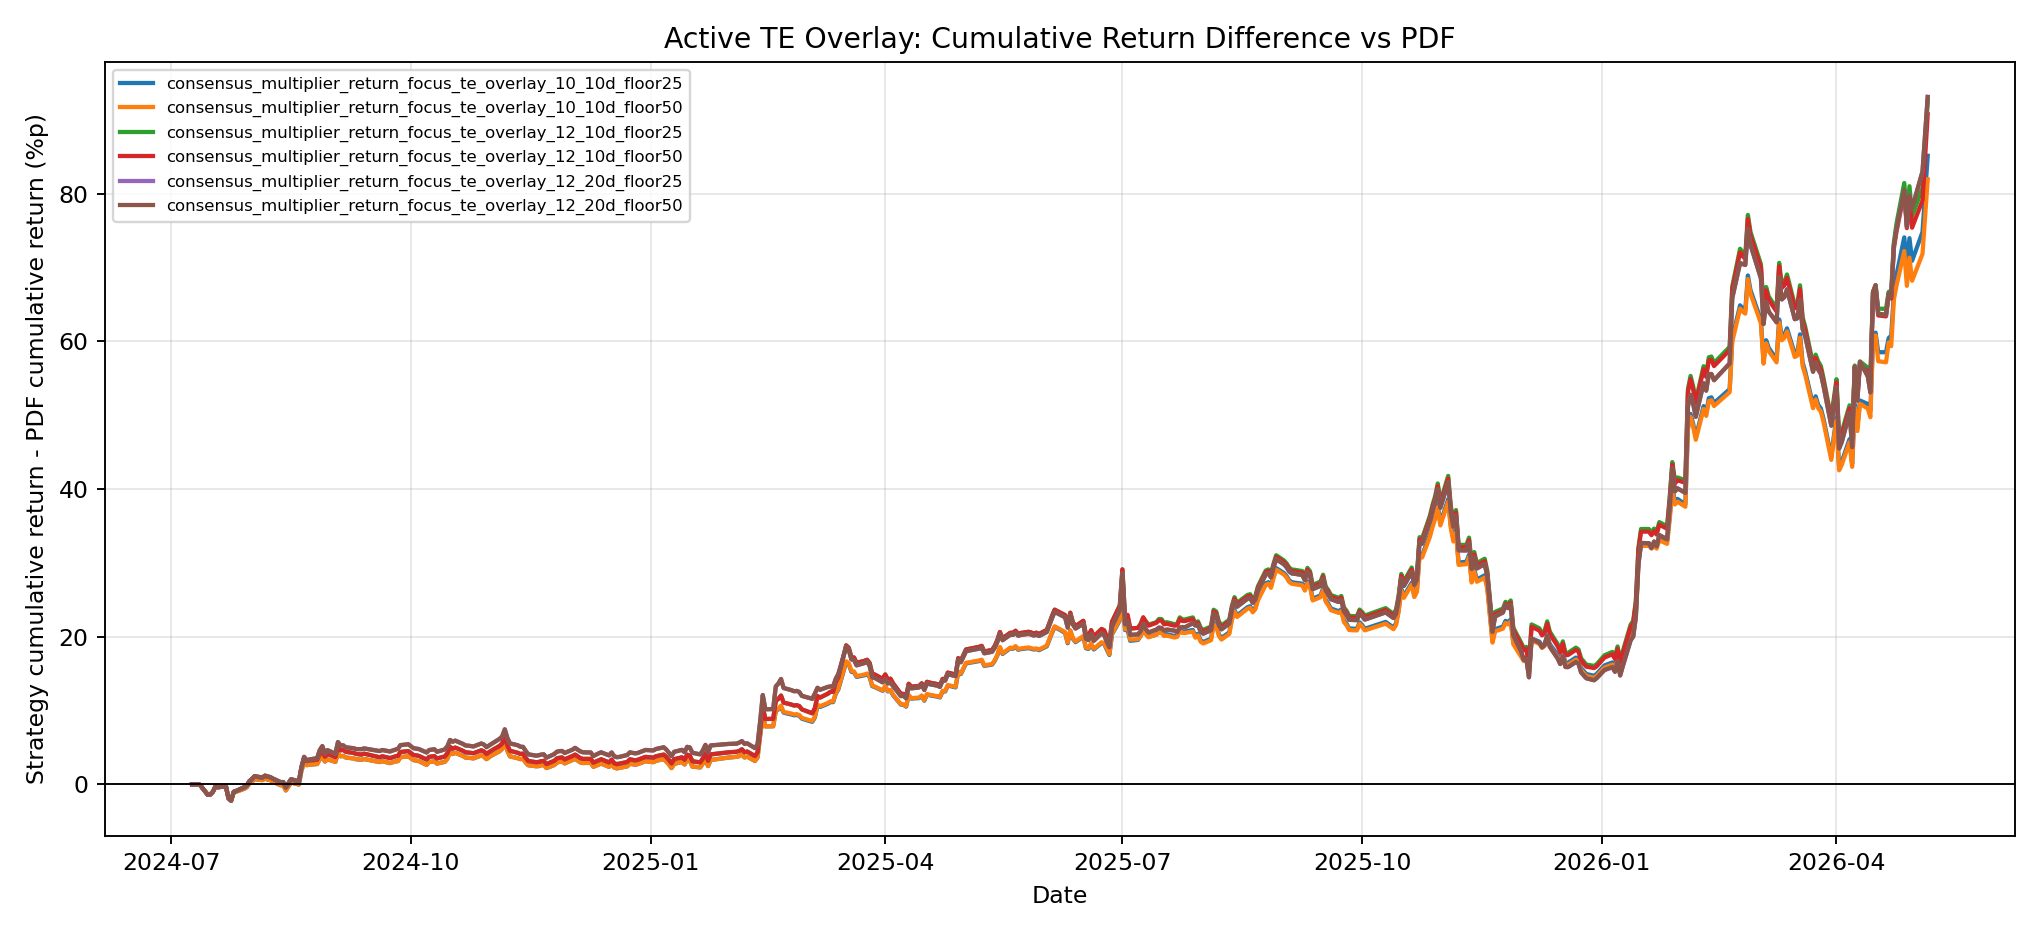

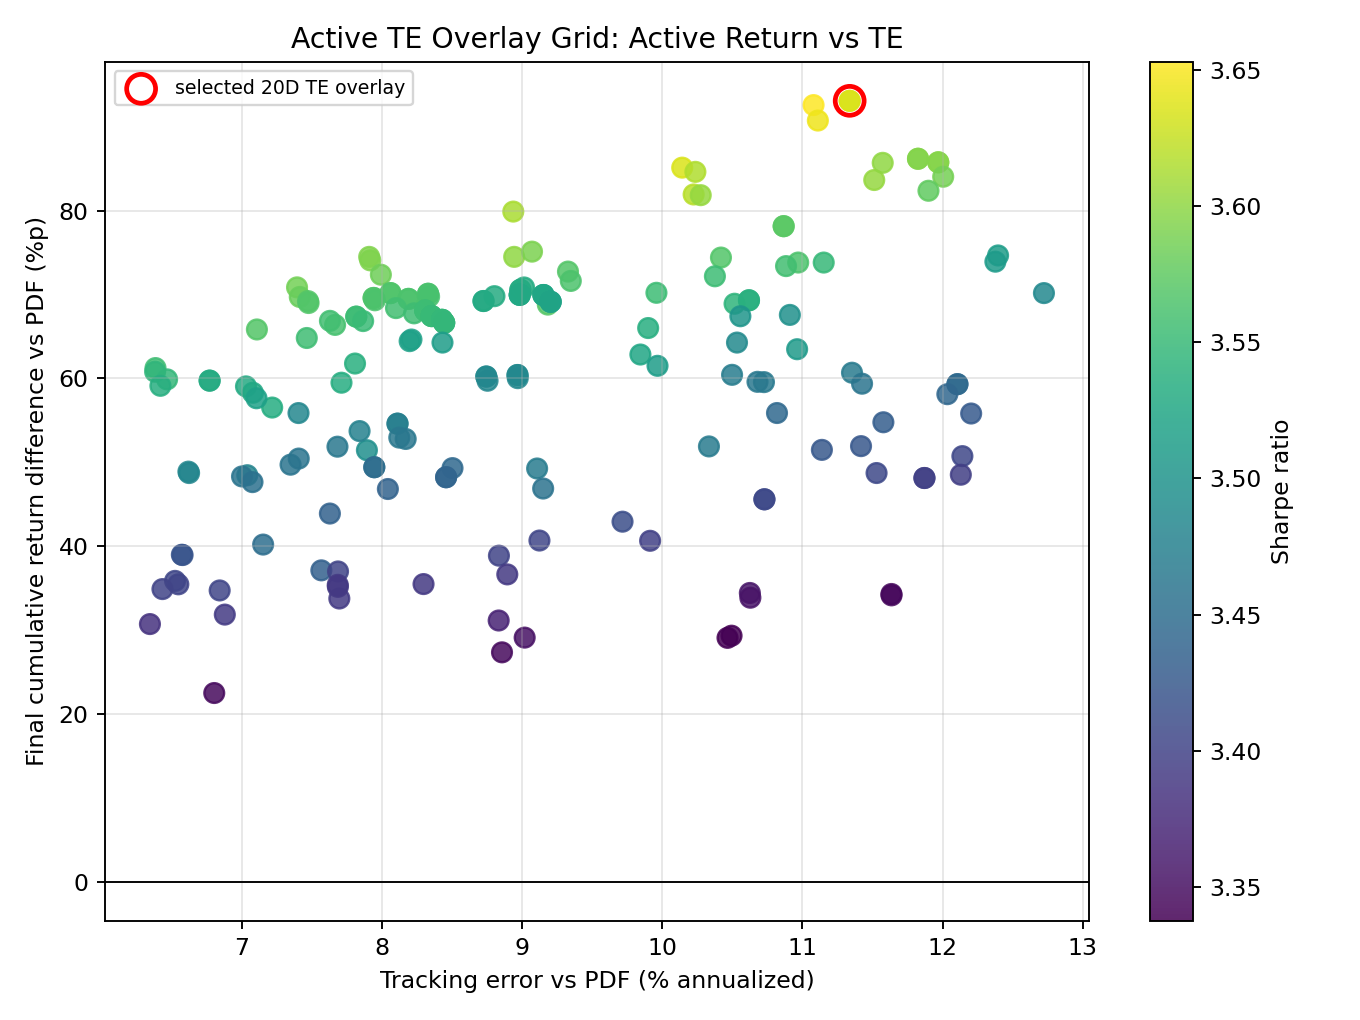

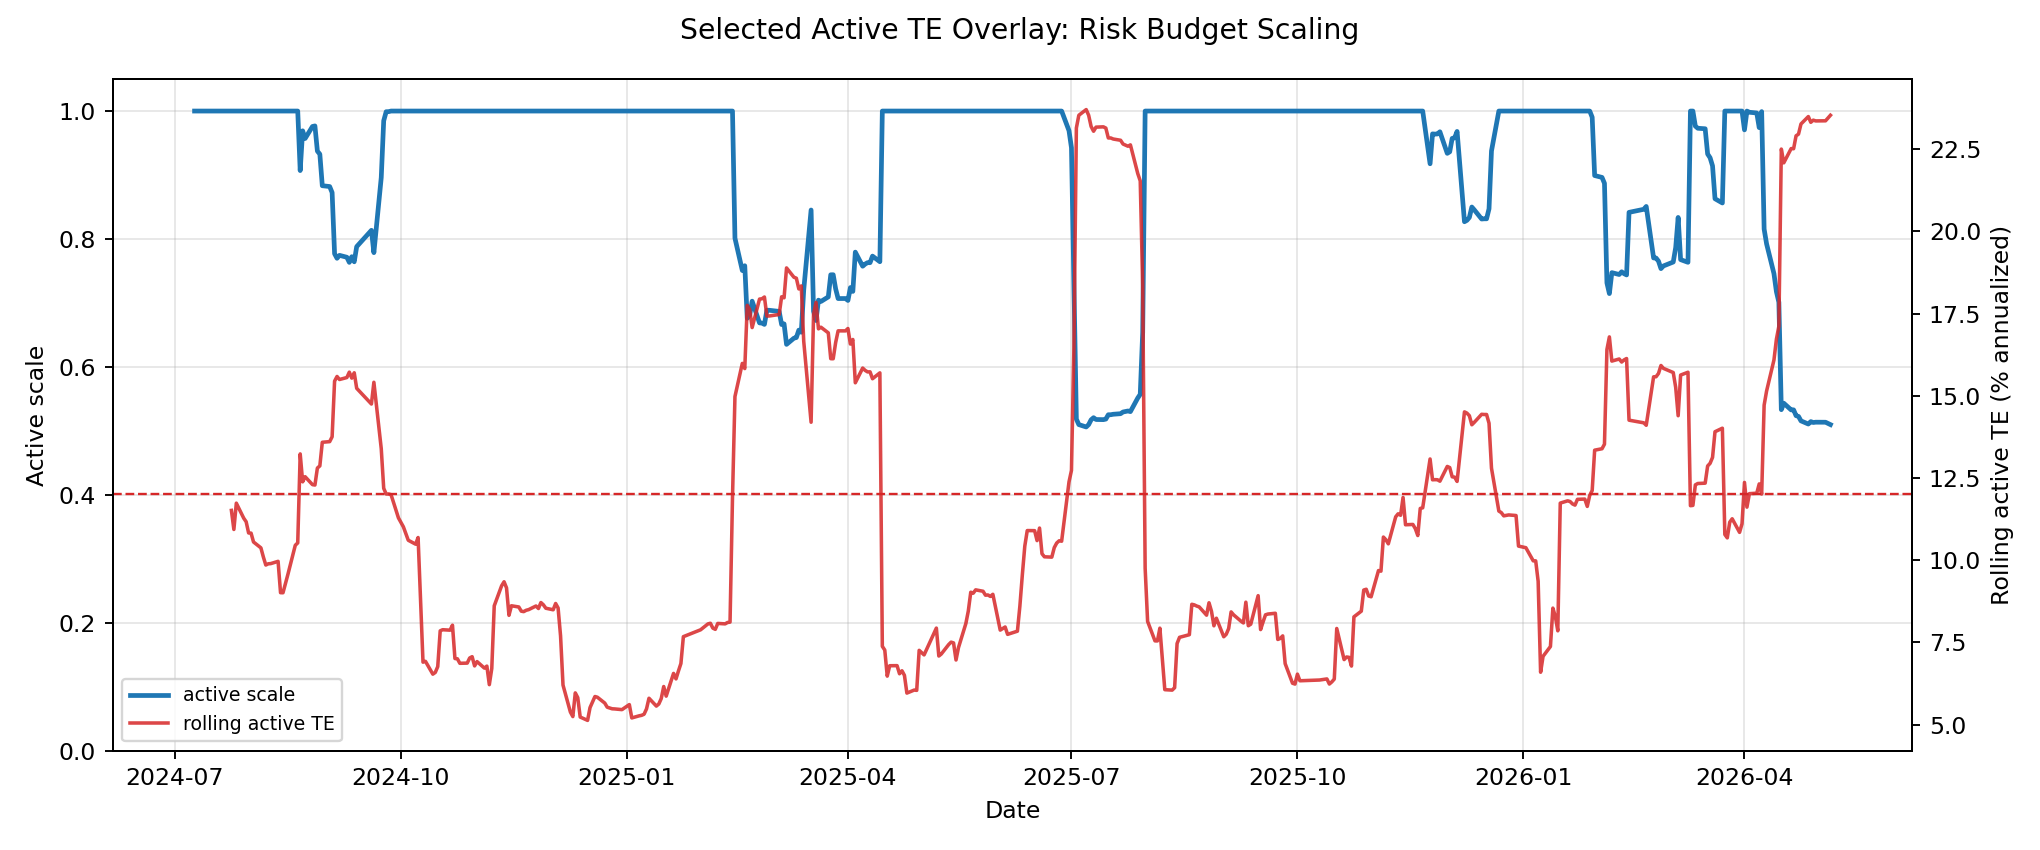

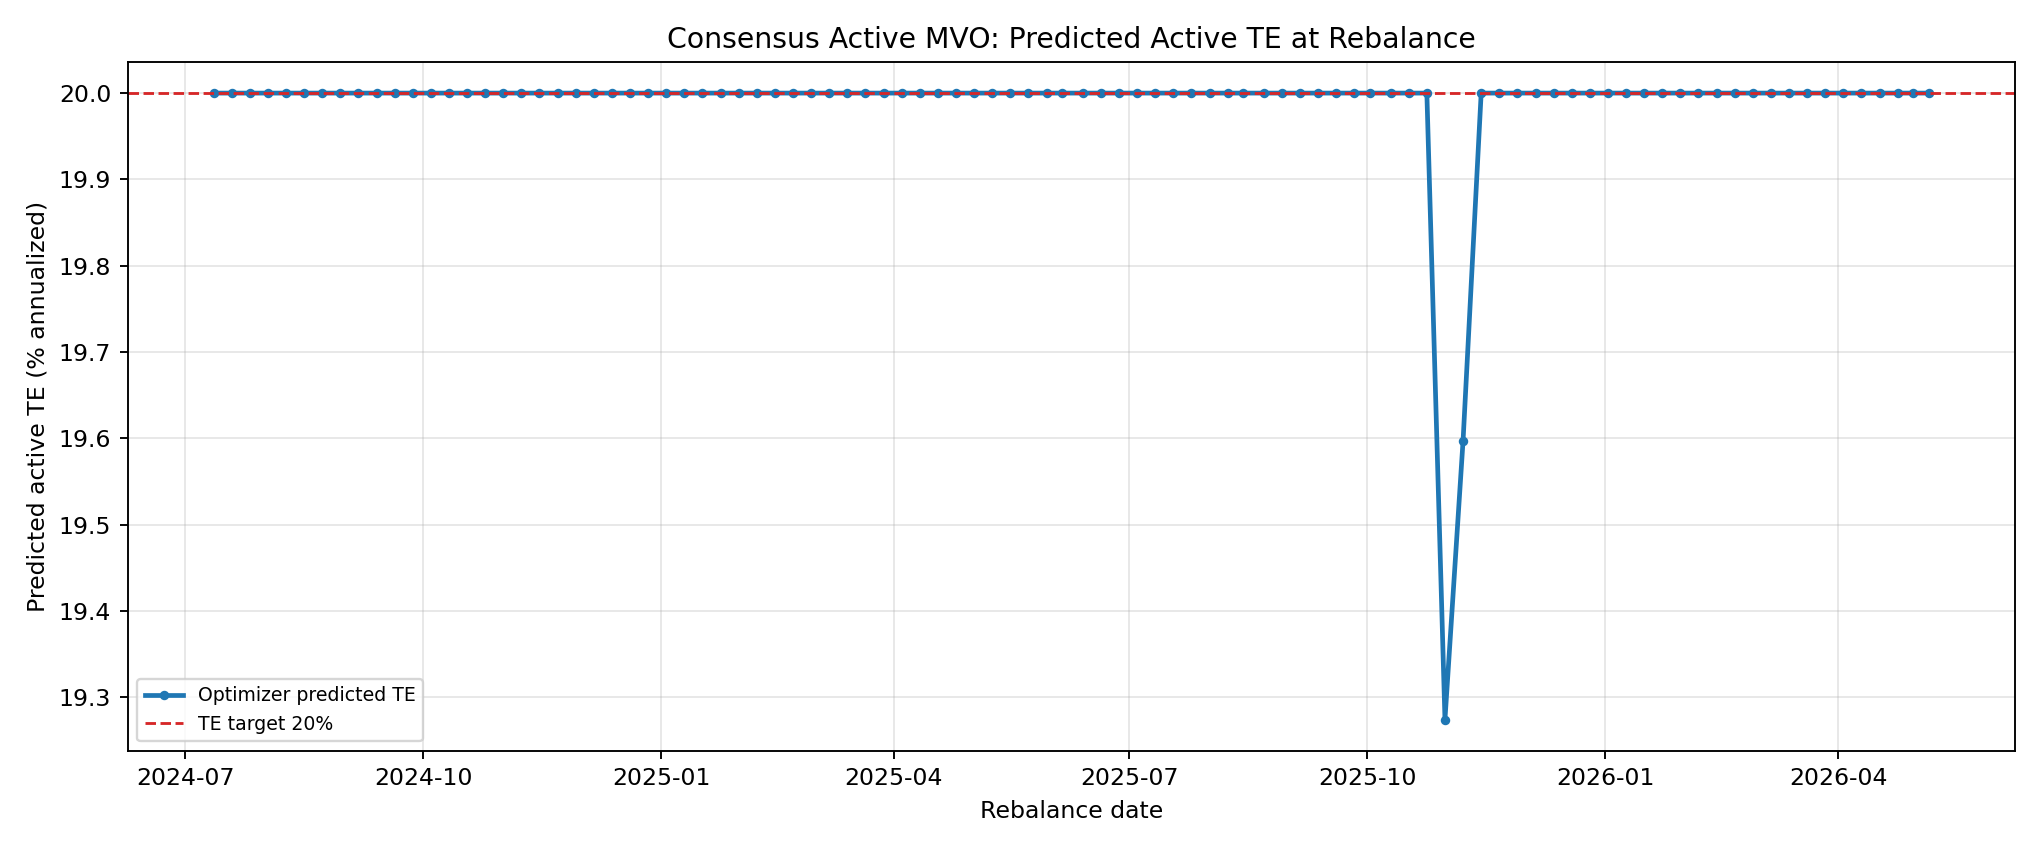

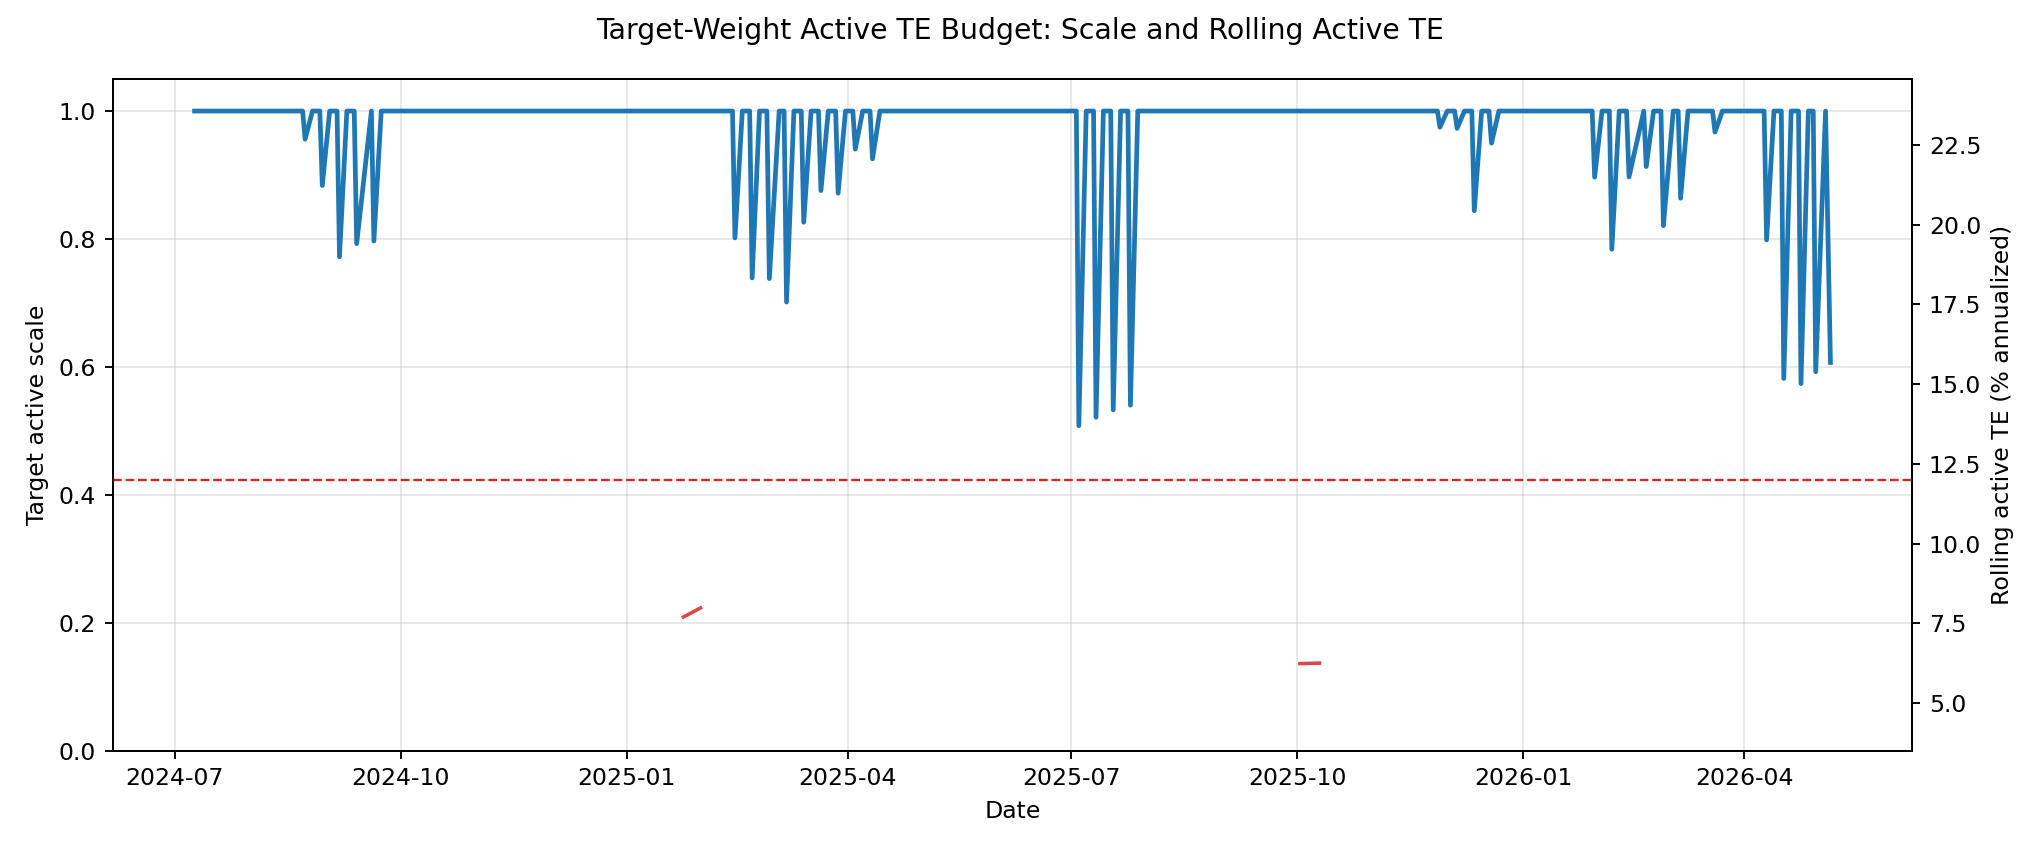

In [6]:
for image_name in [
    'chart_active_te_overlay_active_return.png',
    'chart_active_te_overlay_return_vs_te.png',
    'chart_active_te_overlay_scale.png',
    'chart_consensus_active_mvo_predicted_te.png',
    'chart_consensus_te_budget_scale.png',
]:
    display(Image(filename=str(OUTPUT / image_name)))

## 2-1. 연구 기반 후보를 그대로 쓰지 않은 이유

현재 데이터로 추가 검토한 연구 기반 후보는 다음입니다.

| 아이디어 | 현재 구현 | 결과 해석 |
|---|---|---|
| Revision momentum | EPS/OP revision과 목표주가 revision으로 proxy 구성 | 일부 후보에서 balanced보다 약간 개선 |
| 사이즈 | `log_market_cap` | ETF 내부 IC가 가장 양호한 축 중 하나 |
| 밸류 | `1/PER`, `1/PBR`, `1/PSR` | 단독 IC는 일부 양호하지만 value/profitability/low-risk 묶음은 성과 약함 |
| 수익성 | 영업이익률, 순이익률, EPS yield | 이 ETF 구간에서는 단독 주도 팩터로 약함 |
| 저위험 | 변동성 낮은 종목 선호 | 테마 상승장에서는 오히려 성과를 눌러서 메인 후보에서 제외 |

따라서 최종 후보는 “문헌상 유명한 팩터를 그대로 다 넣은 모델”이 아니라, 현재 ETF 유니버스에서 실제 성과와 IC가 확인된 후보만 남긴 구조입니다.

## 3. 그래프로 보기

첫 번째 그래프는 PDF 대비 단순 누적수익률 차이입니다. y축이 0보다 높으면 전략 누적수익률이 PDF 벤치마크보다 높다는 뜻입니다.

두 번째 그래프는 TE와 단순 누적수익률 차이의 trade-off입니다. 오른쪽으로 갈수록 ETF와 더 다르게 움직이고, 위로 갈수록 PDF 대비 누적수익률 차이가 큽니다.

세 번째 MVO predicted TE 그래프는 최종 MVO 전략이 리밸런싱 시점마다 예상 active TE를 얼마로 맞췄는지 보여줍니다. 파란 선이 20% 점선 근처에 있으면 최적화가 TE budget을 적극적으로 사용하고 있다는 뜻입니다.

네 번째 scale 그래프는 비교용 `consensus_return_focus_te_budget` 전략이 언제 active exposure를 줄였는지 보여줍니다. 최종 MVO 전략은 별도의 scale 규칙이 아니라 공분산 기반 최적화 제약으로 active risk를 관리합니다.

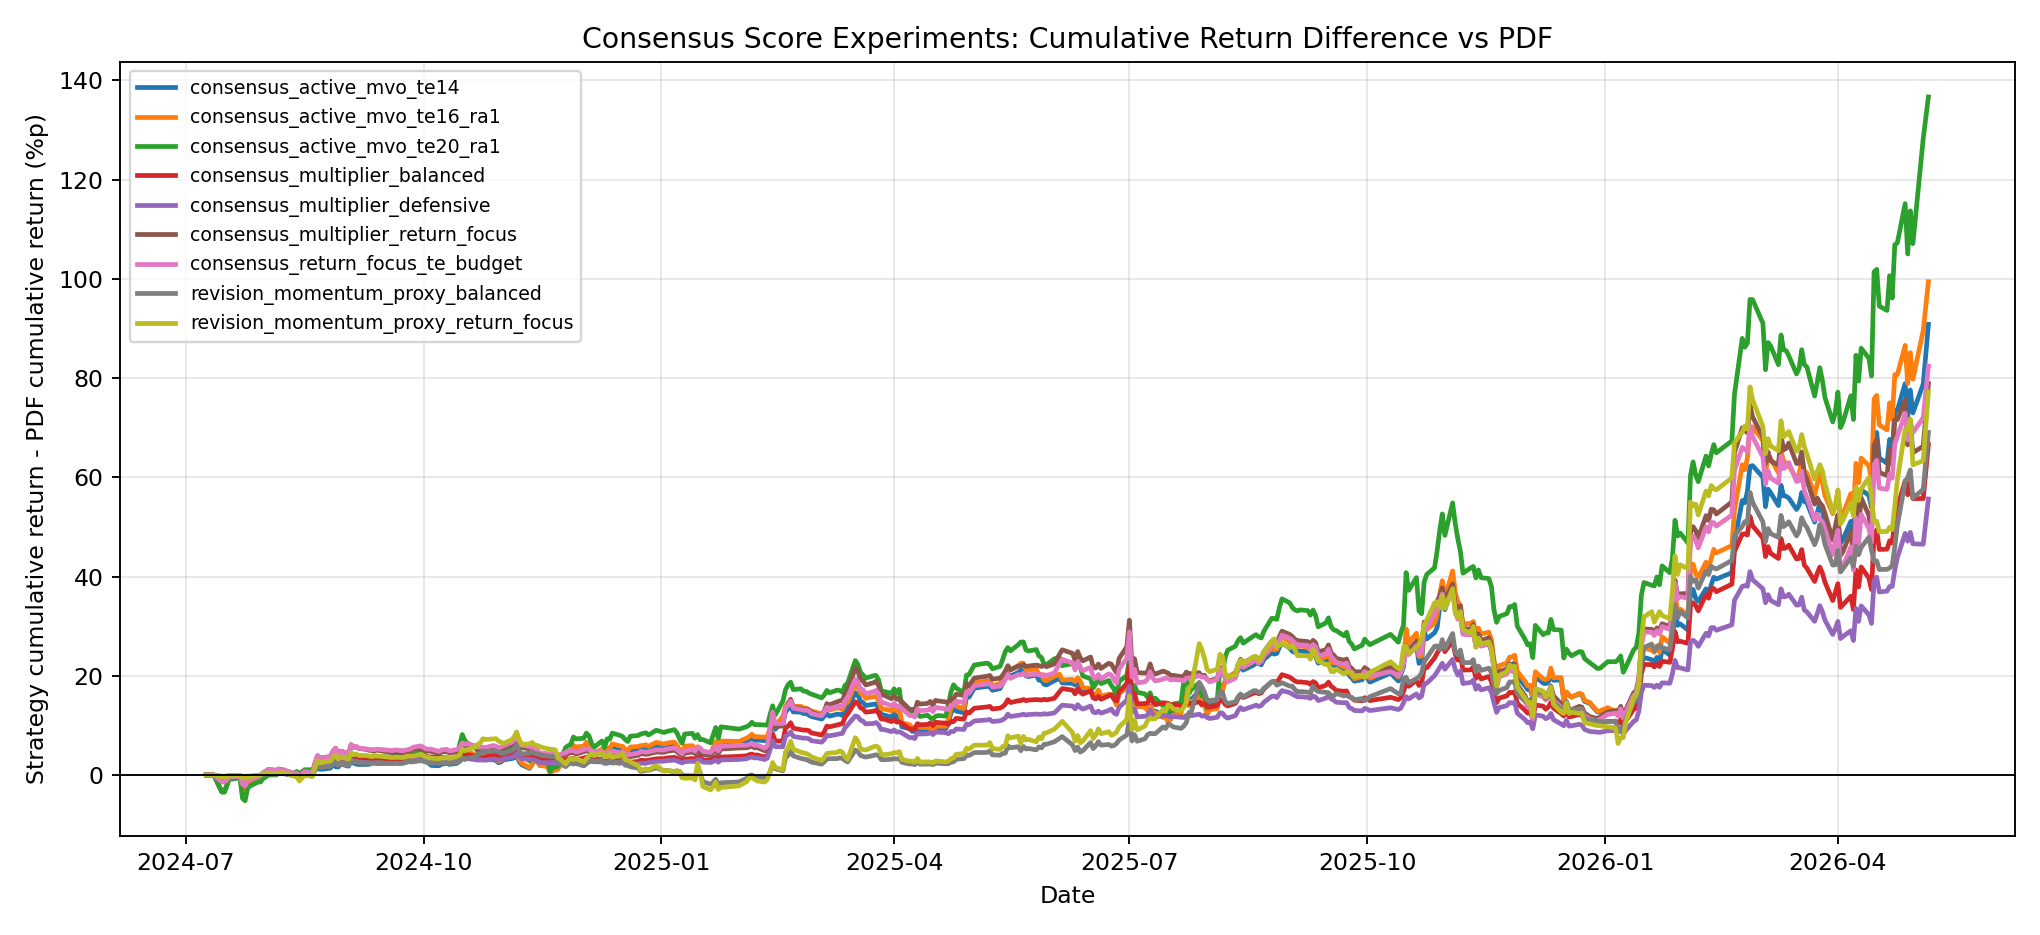

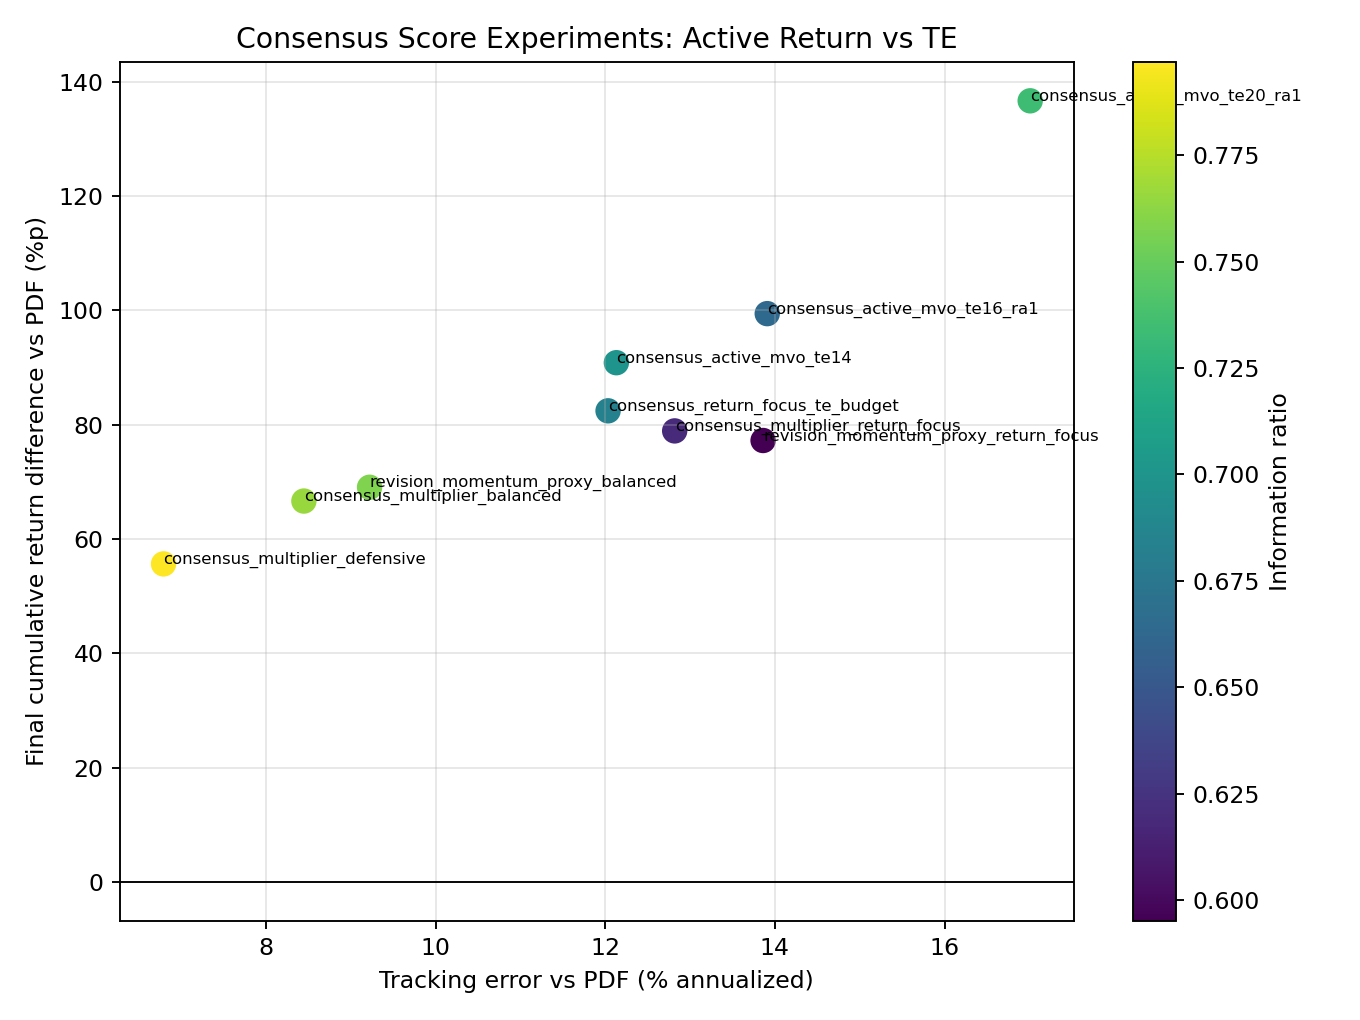

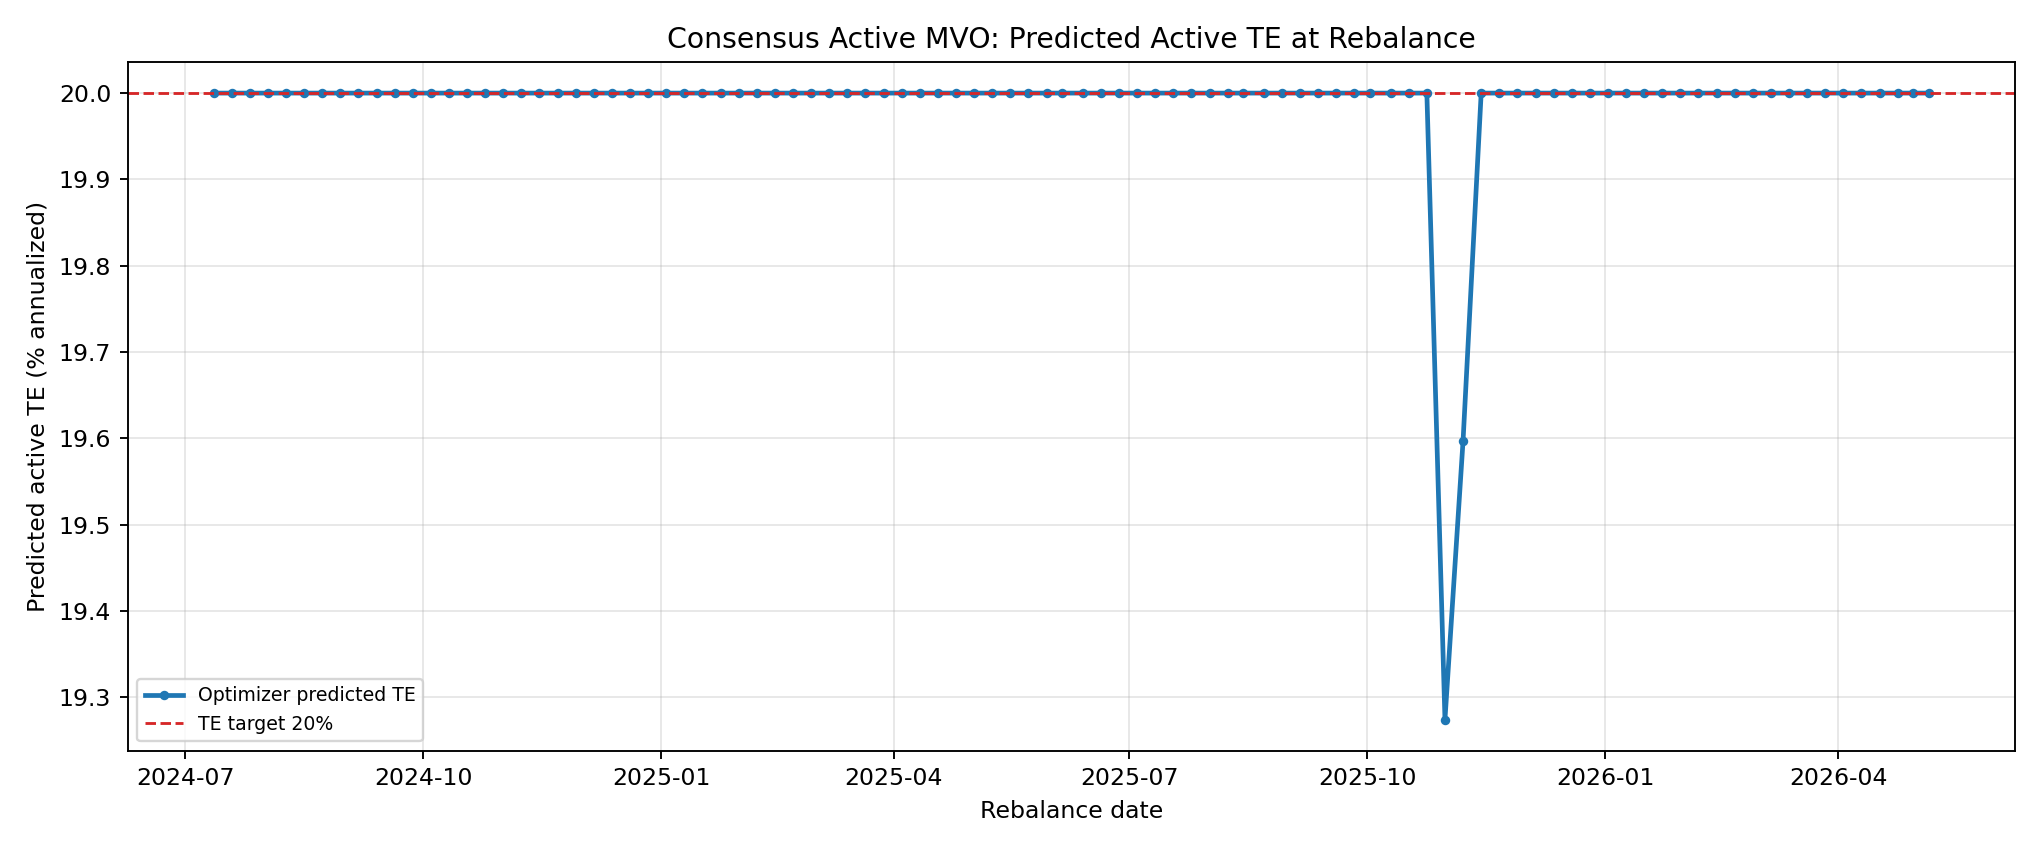

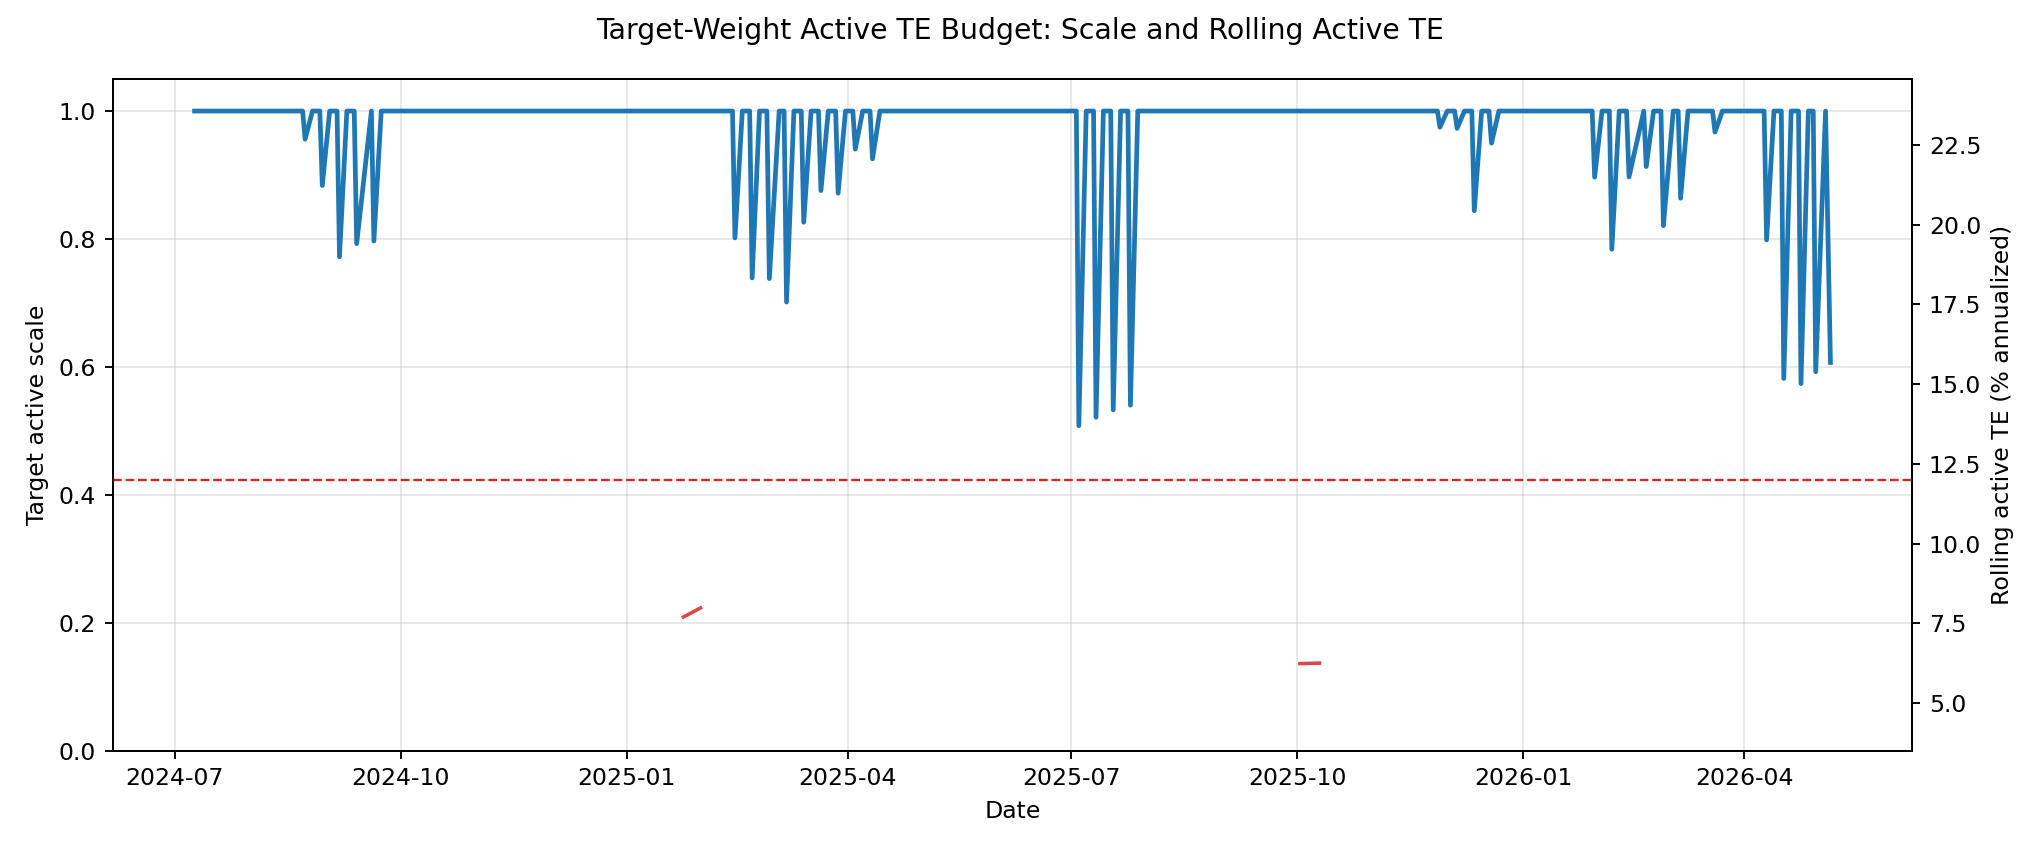

In [7]:
for image_name in [
    'chart_consensus_score_experiment_active_return.png',
    'chart_consensus_score_return_vs_te.png',
    'chart_consensus_active_mvo_predicted_te.png',
    'chart_consensus_te_budget_scale.png',
]:
    display(Image(filename=str(OUTPUT / image_name)))

## 3-1. 그래프별 해석

### 1) Cumulative return difference vs PDF

이 그래프의 y축은 “전략 누적수익률 - PDF 벤치마크 누적수익률”입니다. 그래서 y축이 0보다 높다는 것은 단순히 절대수익률이 높다는 뜻이 아니라, **같은 ETF 바스켓을 기준으로 비중을 다르게 둔 전략이 PDF보다 더 벌었다**는 뜻입니다.

마지막 값 기준으로 보면 `consensus_active_mvo_te20_ra1`은 PDF 대비 약 **+136.66%p**의 누적 초과성과를 냅니다. 규칙형 TE budget 후보인 `consensus_return_focus_te_budget`의 +82.42%p보다 높습니다. 즉 공분산 기반 MVO는 단순 multiplier보다 더 적극적으로 score exposure를 사용하면서도 active risk를 제약조건으로 관리했습니다.

### 2) Return vs TE scatter

이 산점도는 전략 선택에서 가장 중요합니다.

- x축: PDF 대비 연율화 tracking error
- y축: PDF 대비 최종 누적 초과수익률(%p)
- 색: information ratio

왼쪽 위에 있을수록 같은 벤치마크 이탈 위험을 덜 쓰면서 더 많은 초과성과를 낸 후보입니다. 최종 MVO 후보는 TE를 약 17.01% 사용하지만, PDF 대비 초과성과와 Sharpe가 가장 높아 최종 후보로 선택했습니다. 더 보수적인 발표 톤이 필요하면 `consensus_active_mvo_te14`를 대안으로 같이 언급할 수 있습니다.

### 3) MVO predicted TE

이 그래프는 최종 MVO 후보가 리밸런싱 시점마다 공분산 행렬 기준 예상 active TE를 얼마로 계산했는지 보여줍니다.

- x축은 리밸런싱 날짜입니다.
- y축은 최적화 시점의 예상 active TE입니다.
- 빨간 점선은 TE target 20%입니다.

파란 선이 20% 근처에 있다는 것은 최적화가 risk budget을 거의 꽉 쓰면서 score exposure를 최대화했다는 뜻입니다. 즉 이 전략은 단순히 “점수 높은 종목을 많이 담은 것”이 아니라, PDF 대비 active risk 한도 안에서 점수 노출을 최대화한 전략입니다.

### 4) Target-weight TE budget scale

이 그래프는 최종 MVO 후보가 아니라, 비교용 규칙형 TE budget 전략의 리스크관리 장치가 실제로 작동했는지 보여줍니다.

- 파란색: active scale
- 빨간색: 과거 20영업일 rolling active TE
- 빨간 점선: active TE target 12%

rolling active TE가 12%보다 높아지면 active scale이 1보다 낮아집니다. 예를 들어 2025년 7월에는 rolling active TE가 약 23.6%까지 올라가 scale이 약 50.8%까지 내려갑니다. 이 말은 PDF에서 공격형 target으로 가는 이동폭의 절반 정도만 반영했다는 뜻입니다.

중요한 점은 평균 active scale이 약 98.36%라는 것입니다. 즉 대부분의 기간에는 신호를 거의 그대로 사용했고, active risk가 급격히 커진 구간에서만 노출을 줄였습니다. 그래서 이 전략은 “항상 보수적인 전략”이 아니라 **필요한 시점에만 속도를 줄이는 리스크관리형 active overlay**로 해석하는 것이 맞습니다.

### 5) Active TE overlay grid

별도로 active return sleeve에 TE budget을 씌운 참고 실험도 확인했습니다. 여기서는 20영업일 lookback, 12% TE target 후보가 누적수익률 588.96%, PDF 대비 +93.08%p, Sharpe 3.64, IR 0.79로 가장 설득력 있는 후보 중 하나였습니다.

다만 발표의 메인 전략은 공분산 기반 최적화로 active risk를 직접 제약한 `consensus_active_mvo_te20_ra1`입니다. active return sleeve overlay는 같은 TE budget 아이디어가 성과 개선으로 이어진다는 참고 실험으로 설명하면 됩니다.

## 4. 결론

이번 실험에서 얻은 결론은 명확합니다.

1. 월말 리밸런싱과 작은 active budget은 너무 약했습니다.
2. PDF 비중에 스코어 multiplier를 곱하면 ETF의 기본 구조를 유지하면서도 성과가 더 살아납니다.
3. `gamma`가 커질수록 점수 반영이 강해지고, 성과와 TE가 함께 커집니다.
4. 리스크 조정형 스코어는 Sharpe를 크게 개선하지 못했지만, 공분산 기반 MVO는 score exposure와 active risk를 동시에 고려하면서 Sharpe와 누적 초과성과를 개선했습니다.
5. 발표에서는 방어형/균형형/공격형/규칙형 TE budget/MVO 최적화 후보를 분리해서 말하는 편이 안전합니다.

추천 후보는 다음처럼 정리합니다.

| 후보 | 해석 |
|---|---|
| `consensus_multiplier_defensive` | 상관계수와 TE를 비교적 방어하는 후보 |
| `consensus_multiplier_balanced` | 성과와 IR의 균형이 좋은 비교 후보 |
| `consensus_multiplier_return_focus` | 누적수익률을 더 키운 공격형 후보 |
| `consensus_return_focus_te_budget` | 공격형 후보의 target weight에 규칙형 active TE 예산 관리를 적용한 비교 후보 |
| `consensus_active_mvo_te20_ra1` | score exposure, 공분산, TE 제약을 함께 고려한 최종 최적화 후보 |
| `revision_momentum_proxy_balanced` | revision momentum proxy를 보조 확인한 후보 |
| `active_te_overlay_selected` | active return sleeve에 TE 예산을 적용한 성과 중심 참고 후보 |

`consensus_multiplier_return_focus`는 누적수익률은 높지만 공분산 구조를 직접 보지 않는 단순 공격형 후보입니다. 최종 발표에서는 `consensus_active_mvo_te20_ra1`을 “PDF 대비 active risk 제약을 둔 최적화형 최종 후보”로 두고, `consensus_return_focus_te_budget`과 `active_te_overlay_selected`는 리스크관리 아이디어의 비교 결과로 설명하는 편이 가장 방어적입니다.

## 4-1. 추가로 받으면 좋은 데이터와 다음 개선 방향

현재 최종 score는 설명 가능성을 우선해서 3개 팩터만 사용합니다.

$$
ConsensusCore
= 0.50z(EPSRevision1M)
+0.30z(TargetUpside)
+0.20z(RatingPoint)
$$

이 구조는 발표용으로 깔끔하지만, 삼성증권 리포트의 5월 전략과 더 가깝게 만들려면 다음 단계에서는 **분기 컨센서스 데이터**를 추가하는 것이 가장 좋습니다.

### 1. 분기별 EPS 컨센서스가 들어오면 만들 수 있는 것

분기별 EPS 컨센서스 시계열이 있으면 삼성 리포트의 `EPS 변화율(FQ1, 1m)`에 해당하는 팩터를 만들 수 있습니다.

$$
EPSRevisionFQ1_{i,t}
=
\frac{
EPSConsensusFQ1_{i,t}
-
EPSConsensusFQ1_{i,t-21}
}{
|EPSConsensusFQ1_{i,t-21}|
}
$$

여기서 21거래일은 약 1개월입니다. 이 팩터는 “다음 분기 EPS 기대치가 최근 한 달 동안 얼마나 상향됐는가”를 보는 신호입니다.

이 데이터가 들어오면 현재 `rating_point`를 대체하거나 보완할 수 있습니다.

```text
SamsungProxyCore_v2
= 0.40 * z(EPS_FY2_revision_1m)
+ 0.35 * z(EPS_FQ1_revision_1m)
+ 0.25 * z(TargetPrice_revision_1m)
```

또는 영업이익 분기 컨센서스까지 들어오면 다음처럼 더 삼성 리포트에 가깝게 만들 수 있습니다.

```text
SamsungProxyCore_v3
= 0.35 * z(EPS_FY2_revision_1m)
+ 0.30 * z(OP_FQ1_revision_1m)
+ 0.20 * z(TargetPrice_revision_1m)
+ 0.15 * z(VolAdjusted_EPS_revision_1m)
```

### 2. DataGuide에서 추가로 받으면 좋은 항목

| 우선순위 | DataGuide 데이터 | 만들 수 있는 팩터 | 용도 |
|---:|---|---|---|
| 1 | 분기 EPS 컨센서스 FQ1 일별 시계열 | `eps_revision_fq1_1m` | 다음 분기 이익 전망 변화 |
| 2 | 분기 영업이익 컨센서스 FQ1 일별 시계열 | `op_revision_fq1_1m` | 다음 분기 영업이익 전망 변화 |
| 3 | 일별 목표주가 평균 시계열 | `target_price_revision_21d` | 목표가 변화율, analyst sentiment momentum |
| 4 | 분기 actual 실적, 발표일, 전년동기 실적 | `op_growth_fq0_yoy`, surprise factor | 실적 발표 이후 drift/성장성 검증 |
| 5 | WICS/업종코드와 업종별 universe | `relative_forward_per` | 삼성의 업종 대비 상대 P/E에 가까운 proxy |

### 3. 왜 이 데이터가 중요한가

현재 데이터로도 연간 EPS revision, 목표주가 괴리율, 투자의견 점수는 만들 수 있습니다. 하지만 삼성 리포트가 강조한 “다음 분기 실적 분위기”는 분기 EPS/영업이익 컨센서스가 있어야 더 정확히 잡힙니다.

따라서 다음 개선은 팩터를 무작정 늘리는 것이 아니라, 현재 3팩터 구조를 유지하되 `rating_point`처럼 느리게 움직이는 보조 sentiment를 **FQ1 EPS revision 또는 FQ1 OP revision**으로 바꿔보는 방향이 가장 좋습니다.

발표에서는 이렇게 말할 수 있습니다.

> 현재 최종 전략은 데이터 안정성과 설명 가능성을 위해 EPS revision, 목표주가 관련 신호, 투자의견 점수의 3개 팩터만 사용했습니다. 향후 분기 EPS/영업이익 컨센서스가 추가되면 삼성증권 리포트의 FQ1 revision 팩터를 더 정확히 구현해, 현재의 rating point를 대체하거나 보완할 계획입니다.


## 5. 최신 종목별 스코어

In [8]:
signals = pd.read_csv(OUTPUT / 'advanced_experiment_signals.csv', parse_dates=['date'])
latest_date = signals['date'].max()
latest = signals[
    signals['date'].eq(latest_date)
    & signals['experiment_name'].eq('consensus_active_mvo_te20_ra1')
].sort_values('consensus_score', ascending=False)

cols = [
    'date',
    'stock_code',
    'stock_name',
    'eps_revision_1m',
    'target_upside',
    'rating_point',
    'consensus_score',
    'benchmark_weight',
    'final_weight_after_turnover_limit',
    'final_active_weight',
]
display(fmt_table(
    latest[cols],
    pct_cols=['eps_revision_1m', 'target_upside', 'benchmark_weight', 'final_weight_after_turnover_limit', 'final_active_weight'],
    num_cols=['rating_point', 'consensus_score'],
))

/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_38543/1608490557.py:1: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  signals = pd.read_csv(OUTPUT / 'advanced_experiment_signals.csv', parse_dates=['date'])


,date,stock_code,stock_name,eps_revision_1m,target_upside,rating_point,consensus_score,benchmark_weight,final_weight_after_turnover_limit,final_active_weight
12638,2026-05-06,298040,효성중공업,7.30%,9.34%,4.000,0.665,18.02%,41.77%,23.75%
12636,2026-05-06,229640,LS에코에너지,16.56%,-19.72%,4.000,0.662,1.23%,9.39%,8.16%
12633,2026-05-06,60370,LS마린솔루션,14.49%,-18.60%,4.000,0.522,1.14%,9.31%,8.17%
12628,2026-05-06,1440,대한전선,12.82%,-20.37%,4.000,0.339,10.89%,15.71%,4.82%
12631,2026-05-06,10120,LS ELECTRIC,9.49%,-17.79%,4.000,0.135,24.63%,20.74%,-3.90%
12637,2026-05-06,267260,HD현대일렉트릭,-0.11%,11.68%,4.000,0.121,12.75%,2.13%,-10.62%
12627,2026-05-06,500,가온전선,,,,-0.066,5.39%,0.95%,-4.44%
12630,2026-05-06,6340,대원전선,,,,-0.066,1.43%,0.00%,-1.43%
12632,2026-05-06,33100,제룡전기,,,,-0.066,1.38%,0.00%,-1.38%
12634,2026-05-06,62040,산일전기,3.20%,-11.04%,4.000,-0.202,5.52%,0.00%,-5.52%


### 최신 스코어 그래프 해석

이 그래프는 가장 최근 리밸런싱일 기준으로 각 종목의 consensus score가 높았는지 낮았는지를 보여줍니다.

해석 방식은 단순합니다.

- score가 높은 종목: PDF 비중보다 더 담는 후보
- score가 낮은 종목: PDF 비중보다 덜 담는 후보
- score가 0 근처인 종목: PDF 비중과 크게 다르지 않게 유지

최신일 기준으로 효성중공업, LS에코에너지, LS마린솔루션, 대한전선 쪽의 점수가 상대적으로 높게 나왔습니다. 반대로 일진전기, LS 등은 점수가 낮아 PDF 대비 underweight 후보가 되었습니다.

다만 이 점수는 종목을 새로 고르는 신호가 아닙니다. ETF 구성종목 안에서 상대적으로 더 담을지 덜 담을지를 결정하는 신호입니다.

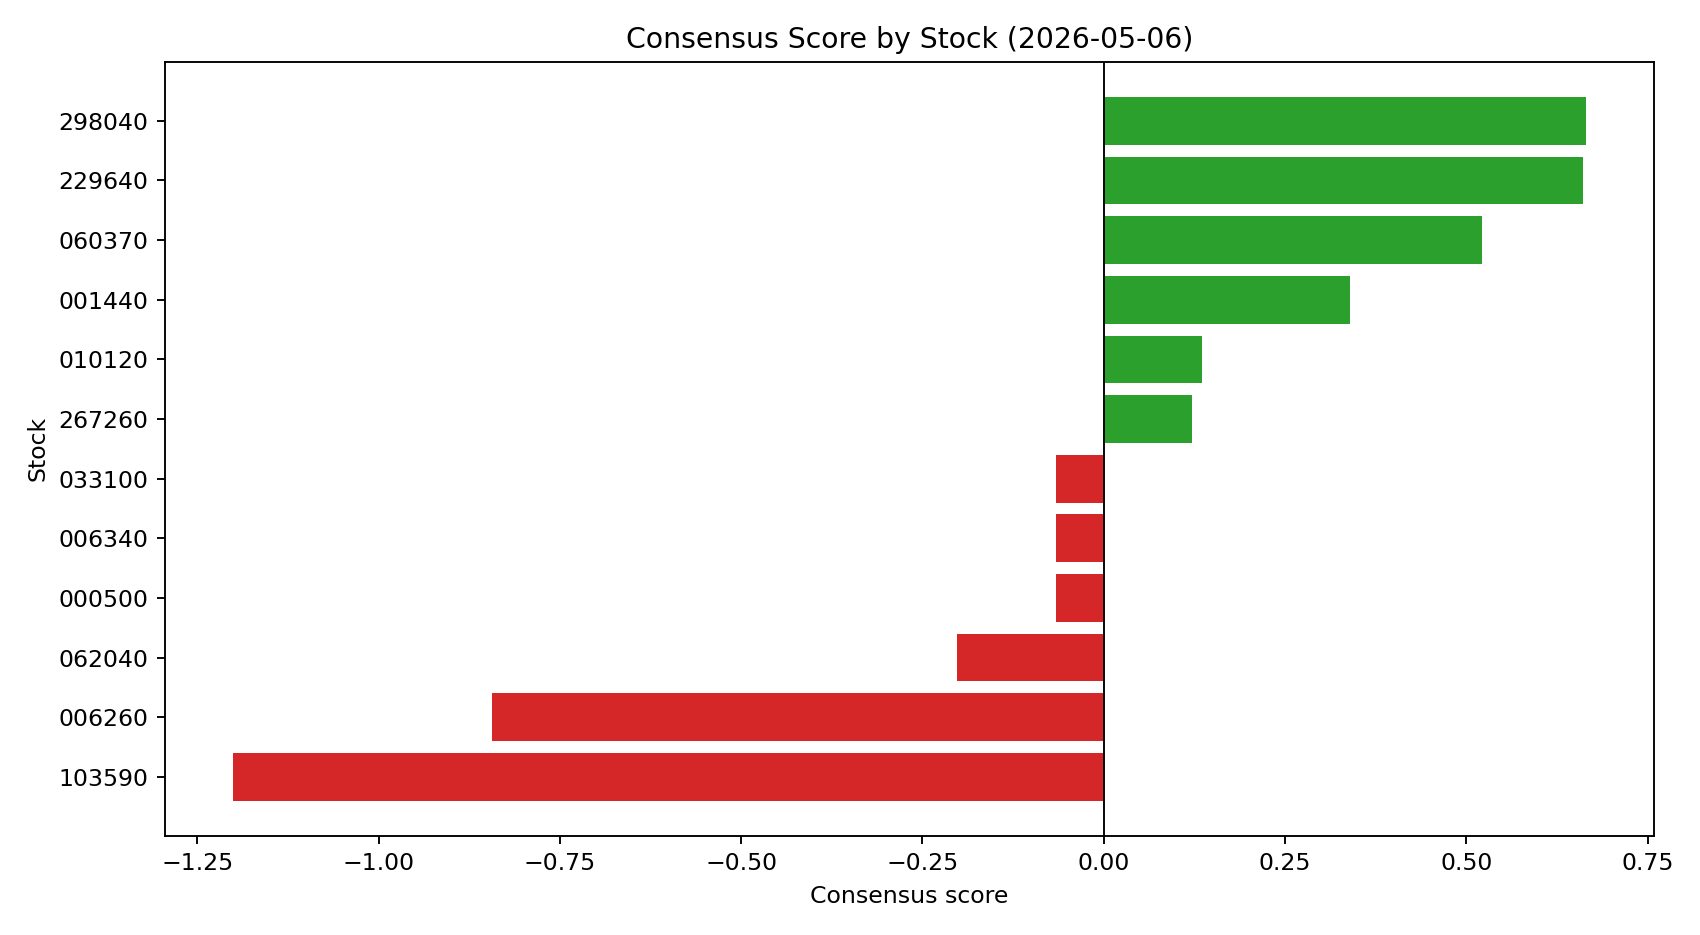

In [9]:
display(Image(filename=str(OUTPUT / 'chart_consensus_score_latest_scores.png')))